# LSEG mid-cap FinBERT baseline evidence reconciliation

**Objective.** Reconcile the previously frozen 22-company Reuters/LSEG mid-cap
FinBERT event strategy with the final-experiments evidence hierarchy. The run was
documented as a positive-Sharpe research baseline but was absent from Notebook 44.
This notebook asks two bounded questions:

1. What result is actually bound by the immutable run artifacts?
2. Does that result qualify as the current strategy base or as sentiment alpha under
   the already-declared ordinal policy?

This is an **aggregate-only reconciliation**, not a new strategy experiment. It reads
the frozen config, run manifest, metrics, bootstrap summary, and per-stock aggregate
contributions. It does not read the corpus, scores, prices, daily P&L, positions,
session construction, or headline text; it launches no scorer and constructs no new
return. The mid-cap LSEG regime remains separate from FNSPID and from the sector/expanded
LSEG/Gemma robustness arm.


In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import tomllib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sentiment_benchmark.strategy_research.baseline.config import load_baseline_config

SEED = 20260806
np.random.seed(SEED)

ROOT = Path.cwd()
if not (ROOT / "final_experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "final_experiments").exists(), "Run from the repository root or final_experiments/."

OUTPUT = ROOT / "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation"
OUTPUT.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)

RUN_ID = "recent-news-midcap-finbert-event-v1-dfdd88113a5f"
RUN_DIR = ROOT / "results/strategy_research/baselines" / RUN_ID
PATHS = {
    "config": ROOT / "configs/strategy_research/baselines/recent_news_midcap_finbert_event_v1.toml",
    "manifest": RUN_DIR / "manifest.json",
    "metrics": RUN_DIR / "metrics.json",
    "bootstrap": RUN_DIR / "bootstrap.json",
    "stock_metrics": RUN_DIR / "stock_metrics.json",
}


def read_json(path: Path) -> dict:
    assert path.suffix == ".json", f"Aggregate-only boundary violated: {path}"
    return json.loads(path.read_text())


def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


def git_commit() -> str:
    return subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
    ).stdout.strip()


config = tomllib.loads(PATHS["config"].read_text())
parsed_config = load_baseline_config(PATHS["config"])
run_manifest = read_json(PATHS["manifest"])
metrics = read_json(PATHS["metrics"])
bootstrap = read_json(PATHS["bootstrap"])
stock_metrics = read_json(PATHS["stock_metrics"])

assert run_manifest["run_id"] == RUN_ID
assert run_manifest["status"] == "completed"
assert run_manifest["sample_status"] == "previously_explored"
assert run_manifest["interpretation"] == {
    "confirmatory": False,
    "fidelity": "conceptual_adaptation",
    "retuning_after_result_permitted": False,
}
assert run_manifest["sharing"]["contains_licensed_headline_text"] is False
assert config["run"]["sample_status"] == "previously_explored"
assert config["portfolio"]["cost_bps_per_side"] == 10.0
assert config["portfolio"]["minimum_names_per_side"] == 1
assert config["signal"]["holding_sessions"] == 1

assert parsed_config.config_sha256 == run_manifest["input_identities"]["config_sha256"]
assert parsed_config.to_payload() == run_manifest["config"]
for name in ("metrics", "bootstrap", "stock_metrics"):
    output_record = run_manifest["outputs"][name]
    assert Path(output_record["path"]) == PATHS[name].relative_to(ROOT)
    assert sha256(PATHS[name]) == output_record["sha256"]

source_files = pd.DataFrame(
    [
        {
            "source": name,
            "path": str(path.relative_to(ROOT)),
            "sha256": sha256(path),
        }
        for name, path in PATHS.items()
    ]
)
source_files.to_csv(OUTPUT / "source_files.csv", index=False)

display(
    Markdown(
        f"Validated **{len(source_files)} aggregate/source artifacts** for immutable run "
        f"`{RUN_ID}`. No row-level return, price, score, position, or text file was read."
    )
)


Validated **5 aggregate/source artifacts** for immutable run `recent-news-midcap-finbert-event-v1-dfdd88113a5f`. No row-level return, price, score, position, or text file was read.

## Frozen evidence policy

Notebook 44's ordinal hierarchy is binding. A previously explored, selected result on
an opened outcome window is tier **2** (bounded retrospective evidence), even when it
contains a chronological display split. Sentiment promotion requires all of:

- a favourable net-return interval excluding zero;
- temporal stability from an eligible frozen chronological or external-time test;
- a passed local predeclared gate; and
- evidence tier at least 4.

The original July acceptance rule is preserved as `legacy_local_gate`; it is not silently
upgraded into the stricter final-experiments promotion rule.


,period,observations,active_sessions,activity_rate,gross_total_return,net_total_return,net_sharpe,annualized_net_mean,annualized_net_volatility,max_drawdown,breakeven_bps_per_side,average_turnover,max_name_concentration,supported_stocks
0,Development,130,25,19.2%,+8.014%,+3.419%,0.780,+6.90%,8.86%,-4.96%,18.18,0.335,50%,21
1,Evaluation,121,37,30.6%,+11.466%,+4.004%,0.593,+9.42%,15.89%,-4.90%,16.52,0.573,50%,21
2,Combined,251,62,24.7%,+20.399%,+7.560%,0.638,+8.12%,12.71%,-6.03%,17.16,0.450,50%,22


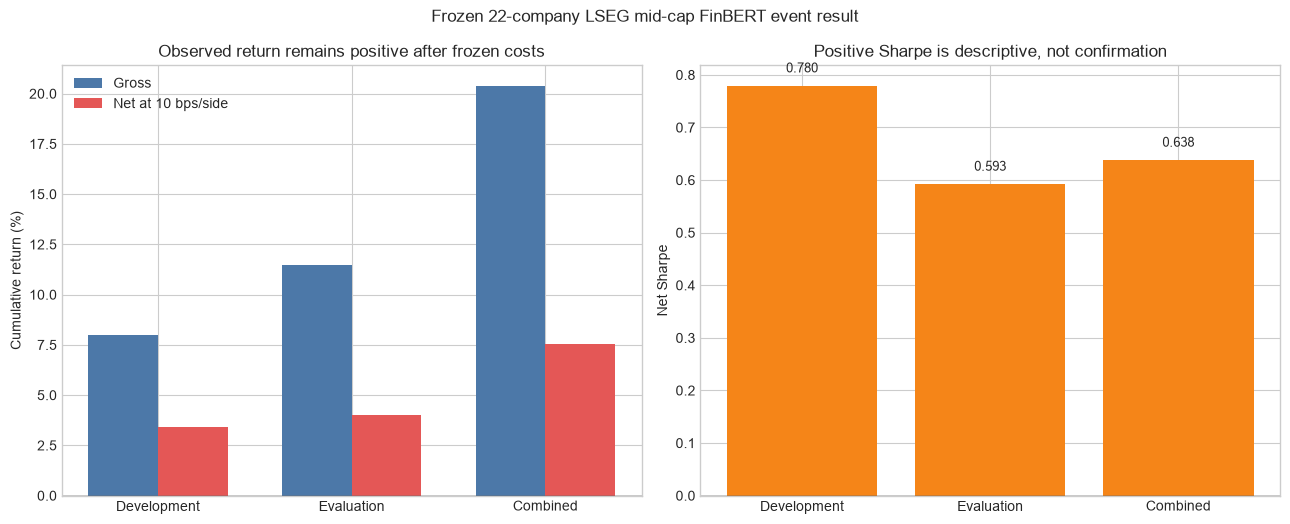

In [2]:
period_order = ["development", "evaluation", "all"]
period_labels = {
    "development": "Development",
    "evaluation": "Evaluation",
    "all": "Combined",
}

period_rows = []
for period in period_order:
    row = metrics["finbert"][period]
    period_rows.append(
        {
            "period": period_labels[period],
            "observations": int(row["observations"]),
            "active_sessions": int(row["active_day_count_excluding_liquidation"]),
            "activity_rate": row["active_day_count_excluding_liquidation"] / row["observations"],
            "gross_total_return": float(row["cumulative_gross_return"]),
            "net_total_return": float(row["cumulative_net_return"]),
            "net_sharpe": float(row["after_cost_sharpe"]),
            "annualized_net_mean": float(row["annualized_mean_return"]),
            "annualized_net_volatility": float(row["annualized_volatility"]),
            "max_drawdown": float(row["maximum_drawdown"]),
            "breakeven_bps_per_side": float(row["breakeven_cost_bps_per_side_approx"]),
            "average_turnover": float(row["average_turnover"]),
            "max_name_concentration": float(row["maximum_name_concentration"]),
            "supported_stocks": int(row["supported_stocks"]),
        }
    )

period_results = pd.DataFrame(period_rows)
period_results.to_csv(OUTPUT / "period_results.csv", index=False)

display(
    period_results.style.format(
        {
            "activity_rate": "{:.1%}",
            "gross_total_return": "{:+.3%}",
            "net_total_return": "{:+.3%}",
            "net_sharpe": "{:.3f}",
            "annualized_net_mean": "{:+.2%}",
            "annualized_net_volatility": "{:.2%}",
            "max_drawdown": "{:.2%}",
            "breakeven_bps_per_side": "{:.2f}",
            "average_turnover": "{:.3f}",
            "max_name_concentration": "{:.0%}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
x = np.arange(len(period_results))
width = 0.36
axes[0].bar(
    x - width / 2,
    100 * period_results["gross_total_return"],
    width,
    label="Gross",
    color="#4c78a8",
)
axes[0].bar(
    x + width / 2,
    100 * period_results["net_total_return"],
    width,
    label="Net at 10 bps/side",
    color="#e45756",
)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xticks(x, period_results["period"])
axes[0].set_ylabel("Cumulative return (%)")
axes[0].set_title("Observed return remains positive after frozen costs")
axes[0].legend()

axes[1].bar(period_results["period"], period_results["net_sharpe"], color="#f58518")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Positive Sharpe is descriptive, not confirmation")
for index, value in enumerate(period_results["net_sharpe"]):
    axes[1].text(index, value + 0.025, f"{value:.3f}", ha="center", fontsize=9)

fig.suptitle("Frozen 22-company LSEG mid-cap FinBERT event result")
fig.tight_layout()
fig.savefig(OUTPUT / "frozen_period_results.png", dpi=180, bbox_inches="tight")
plt.show()


## Inference and concentration audit

The evaluation moving-block bootstrap is the relevant cash comparison. Per-stock P&L
is used only as an already-aggregated concentration diagnostic; no daily or event-level
return is reconstructed.


,comparison,mean_bps_per_session,ci_low_bps_per_session,ci_high_bps_per_session,confidence_level,block_length_sessions,replications,interval_excludes_zero
0,evaluation FinBERT strategy minus cash,+3.736,-8.862,+19.342,0.950000,5,2000,False


,stock_metric_rows,supported_stocks_in_strategy_metrics,largest_absolute_contributor,largest_absolute_contribution_share,top_three_absolute_contribution_share,absolute_contribution_hhi,maximum_observed_name_weight,positive_contributors,negative_contributors
0,21,22,PBF,19.9%,49.1%,0.112,50%,9,12


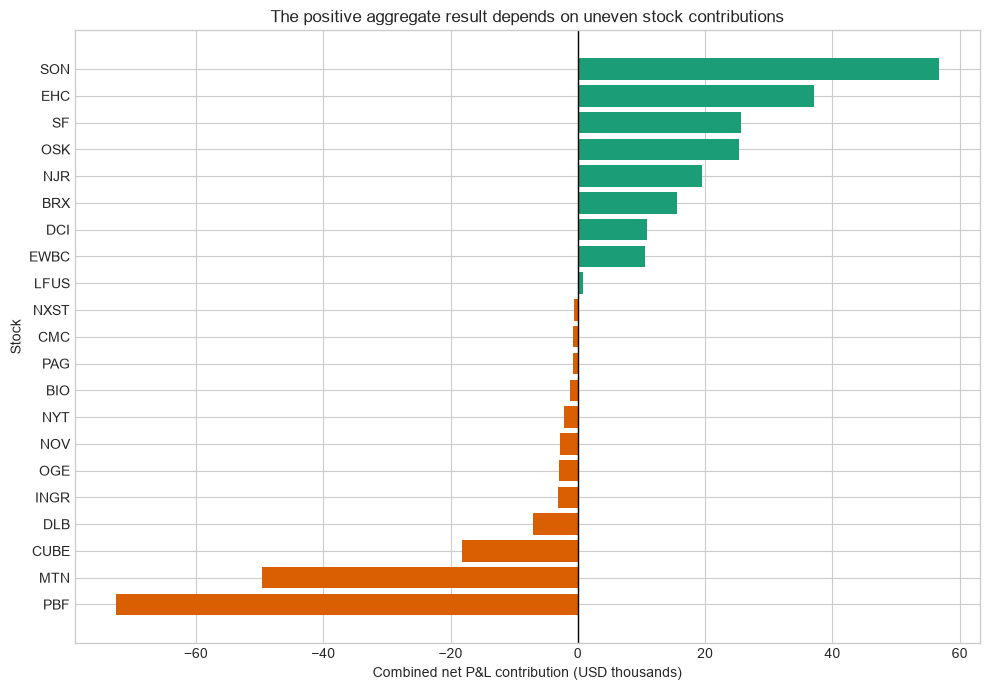

In [3]:
cash_inference = bootstrap["primary_vs_cash"]
assert cash_inference["block_length"] == 5
assert cash_inference["replications"] == 2000
assert cash_inference["confidence_interval_low"] < 0 < cash_inference["confidence_interval_high"]

inference = pd.DataFrame(
    [
        {
            "comparison": "evaluation FinBERT strategy minus cash",
            "mean_bps_per_session": 10_000 * cash_inference["mean_daily_difference"],
            "ci_low_bps_per_session": 10_000 * cash_inference["confidence_interval_low"],
            "ci_high_bps_per_session": 10_000 * cash_inference["confidence_interval_high"],
            "confidence_level": cash_inference["confidence_level"],
            "block_length_sessions": cash_inference["block_length"],
            "replications": cash_inference["replications"],
            "interval_excludes_zero": cash_inference["confidence_interval_low"] > 0,
        }
    ]
)
inference.to_csv(OUTPUT / "evaluation_inference.csv", index=False)

stocks = pd.DataFrame(stock_metrics["finbert"]).copy()
assert not stocks.empty
assert stocks["symbol"].is_unique
assert len(stocks) == 21
stocks["absolute_net_pnl_usd"] = stocks["net_pnl_usd"].abs()
absolute_total = stocks["absolute_net_pnl_usd"].sum()
stocks["absolute_contribution_share"] = stocks["absolute_net_pnl_usd"] / absolute_total
stocks = stocks.sort_values("net_pnl_usd")
stocks.to_csv(OUTPUT / "stock_contributions.csv", index=False)

largest = stocks.loc[stocks["absolute_contribution_share"].idxmax()]
concentration = pd.DataFrame(
    [
        {
            "stock_metric_rows": len(stocks),
            "supported_stocks_in_strategy_metrics": int(metrics["finbert"]["all"]["supported_stocks"]),
            "largest_absolute_contributor": largest["symbol"],
            "largest_absolute_contribution_share": float(largest["absolute_contribution_share"]),
            "top_three_absolute_contribution_share": float(
                stocks.nlargest(3, "absolute_contribution_share")["absolute_contribution_share"].sum()
            ),
            "absolute_contribution_hhi": float(np.square(stocks["absolute_contribution_share"]).sum()),
            "maximum_observed_name_weight": float(metrics["finbert"]["all"]["maximum_name_concentration"]),
            "positive_contributors": int((stocks["net_pnl_usd"] > 0).sum()),
            "negative_contributors": int((stocks["net_pnl_usd"] < 0).sum()),
        }
    ]
)
concentration.to_csv(OUTPUT / "concentration_summary.csv", index=False)

display(inference.style.format({
    "mean_bps_per_session": "{:+.3f}",
    "ci_low_bps_per_session": "{:+.3f}",
    "ci_high_bps_per_session": "{:+.3f}",
}))
display(concentration.style.format({
    "largest_absolute_contribution_share": "{:.1%}",
    "top_three_absolute_contribution_share": "{:.1%}",
    "absolute_contribution_hhi": "{:.3f}",
    "maximum_observed_name_weight": "{:.0%}",
}))

fig, ax = plt.subplots(figsize=(10, 7))
colors = np.where(stocks["net_pnl_usd"] >= 0, "#1b9e77", "#d95f02")
ax.barh(stocks["symbol"], stocks["net_pnl_usd"] / 1_000, color=colors)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Combined net P&L contribution (USD thousands)")
ax.set_ylabel("Stock")
ax.set_title("The positive aggregate result depends on uneven stock contributions")
fig.tight_layout()
fig.savefig(OUTPUT / "stock_contribution_concentration.png", dpi=180, bbox_inches="tight")
plt.show()


## Evidence decision

The legacy local acceptance rule and the final promotion rule answer different
questions. The former asks whether the frozen replay stayed positive across the displayed
split; the latter asks whether the evidence is sufficiently independent, precise, and
stable to become the strategy base.


In [4]:
development = period_results.loc[period_results["period"].eq("Development")].iloc[0]
evaluation = period_results.loc[period_results["period"].eq("Evaluation")].iloc[0]
combined = period_results.loc[period_results["period"].eq("Combined")].iloc[0]

legacy_local_gate = bool(
    development["net_total_return"] > 0
    and development["net_sharpe"] > 0
    and development["active_sessions"] >= 20
    and evaluation["net_total_return"] > 0
    and evaluation["net_sharpe"] > 0
    and evaluation["active_sessions"] >= 20
    and evaluation["breakeven_bps_per_side"] > config["portfolio"]["cost_bps_per_side"]
)
evidence_score = 2
interval_excludes_zero = bool(inference.iloc[0]["interval_excludes_zero"])
eligible_temporal_stability = False
final_promotion_gate = bool(
    legacy_local_gate
    and interval_excludes_zero
    and eligible_temporal_stability
    and evidence_score >= 4
)

gates = pd.DataFrame(
    [
        {"gate": "immutable_artifact_integrity", "pass": True, "role": "input integrity"},
        {"gate": "legacy_local_acceptance", "pass": legacy_local_gate, "role": "historical local rule"},
        {"gate": "evaluation_cash_interval_excludes_zero", "pass": interval_excludes_zero, "role": "final promotion"},
        {"gate": "eligible_temporal_stability", "pass": eligible_temporal_stability, "role": "final promotion"},
        {"gate": "evidence_score_at_least_four", "pass": evidence_score >= 4, "role": "final promotion"},
        {"gate": "final_sentiment_promotion", "pass": final_promotion_gate, "role": "binding decision"},
        {"gate": "deployment_qualified_base", "pass": False, "role": "binding decision"},
    ]
)
gates.to_csv(OUTPUT / "gates.csv", index=False)

registry_row = pd.DataFrame(
    [
        {
            "notebook": 55,
            "strategy": "Sparse mid-cap FinBERT event rule",
            "regime": "LSEG mid-cap 2026 evaluation",
            "sentiment_role": "cross-sectional headline polarity",
            "sharpe_gross": np.nan,
            "sharpe_net": float(evaluation["net_sharpe"]),
            "total_return_net": float(evaluation["net_total_return"]),
            "max_drawdown": float(evaluation["max_drawdown"]),
            "breakeven_bps_per_side": float(evaluation["breakeven_bps_per_side"]),
            "evidence_class": "previously explored selected-baseline reconciliation",
            "evidence_score": evidence_score,
            "local_gate_pass": legacy_local_gate,
            "decision_eligible": final_promotion_gate,
            "decision": "retain as historical LSEG/FinBERT research comparator; not current base or alpha",
        }
    ]
)
registry_row.to_csv(OUTPUT / "strategy_registry_row.csv", index=False)

decision = {
    "run_id": RUN_ID,
    "legacy_local_gate": legacy_local_gate,
    "evidence_score": evidence_score,
    "evaluation_net_return": float(evaluation["net_total_return"]),
    "evaluation_net_sharpe": float(evaluation["net_sharpe"]),
    "evaluation_active_sessions": int(evaluation["active_sessions"]),
    "evaluation_breakeven_bps_per_side": float(evaluation["breakeven_bps_per_side"]),
    "evaluation_mean_bps_per_session": float(inference.iloc[0]["mean_bps_per_session"]),
    "evaluation_ci_low_bps_per_session": float(inference.iloc[0]["ci_low_bps_per_session"]),
    "evaluation_ci_high_bps_per_session": float(inference.iloc[0]["ci_high_bps_per_session"]),
    "maximum_observed_name_weight": float(combined["max_name_concentration"]),
    "interval_excludes_zero": interval_excludes_zero,
    "eligible_temporal_stability": eligible_temporal_stability,
    "sentiment_promoted": final_promotion_gate,
    "deployment_qualified_base": False,
    "role": "historical LSEG/FinBERT strategy-shaped comparator",
    "lseg_gemma_role_unchanged": (
        "separate non-pooled measurement, downside, revision-information, implementation, "
        "and prospective evidence"
    ),
    "new_signal_constructed": False,
    "new_return_constructed": False,
}

display(gates)
display(
    Markdown(
        "### Result\n\n"
        f"- **Observed strategy-shaped result:** development net return/Sharpe are "
        f"**{development['net_total_return']:+.3%}/{development['net_sharpe']:.3f}**; "
        f"evaluation is **{evaluation['net_total_return']:+.3%}/{evaluation['net_sharpe']:.3f}** "
        f"across **{int(evaluation['active_sessions'])}** active sessions. The combined net return/Sharpe are "
        f"**{combined['net_total_return']:+.3%}/{combined['net_sharpe']:.3f}**.\n"
        f"- **Cost margin:** evaluation break-even is **{evaluation['breakeven_bps_per_side']:.2f} bps/side** "
        f"against the frozen **{config['portfolio']['cost_bps_per_side']:.0f} bps/side** charge.\n"
        f"- **Inference:** evaluation mean is **{inference.iloc[0]['mean_bps_per_session']:+.3f} bps/session**, "
        f"95% interval **[{inference.iloc[0]['ci_low_bps_per_session']:+.3f}, "
        f"{inference.iloc[0]['ci_high_bps_per_session']:+.3f}]**. It crosses zero.\n"
        f"- **Concentration:** maximum observed absolute name weight is "
        f"**{combined['max_name_concentration']:.0%}**; the largest absolute stock contribution is "
        f"**{largest['symbol']} ({largest['absolute_contribution_share']:.1%} of absolute stock-level P&L)**.\n"
        "- **Reconciliation:** the original local acceptance gate passes, so deleting the result would be wrong. "
        "But it is tier-2, previously explored evidence selected from a wider search, its interval crosses zero, "
        "and it carries severe single-name concentration. It is therefore the strongest omitted historical "
        "LSEG/FinBERT strategy-shaped comparator—not the current strategy base, deployable alpha, or evidence "
        "that FinBERT beats Gemma.\n"
        "- **Action:** add the row to Notebook 44 and correct stale baseline wording. Keep the exact rule frozen; "
        "do not tune it or pool it with the separate LSEG/Gemma evidence stream."
    )
)


,gate,pass,role
0,immutable_artifact_integrity,True,input integrity
1,legacy_local_acceptance,True,historical local rule
2,evaluation_cash_interval_excludes_zero,False,final promotion
3,eligible_temporal_stability,False,final promotion
4,evidence_score_at_least_four,False,final promotion
5,final_sentiment_promotion,False,binding decision
6,deployment_qualified_base,False,binding decision


### Result

- **Observed strategy-shaped result:** development net return/Sharpe are **+3.419%/0.780**; evaluation is **+4.004%/0.593** across **37** active sessions. The combined net return/Sharpe are **+7.560%/0.638**.
- **Cost margin:** evaluation break-even is **16.52 bps/side** against the frozen **10 bps/side** charge.
- **Inference:** evaluation mean is **+3.736 bps/session**, 95% interval **[-8.862, +19.342]**. It crosses zero.
- **Concentration:** maximum observed absolute name weight is **50%**; the largest absolute stock contribution is **PBF (19.9% of absolute stock-level P&L)**.
- **Reconciliation:** the original local acceptance gate passes, so deleting the result would be wrong. But it is tier-2, previously explored evidence selected from a wider search, its interval crosses zero, and it carries severe single-name concentration. It is therefore the strongest omitted historical LSEG/FinBERT strategy-shaped comparator—not the current strategy base, deployable alpha, or evidence that FinBERT beats Gemma.
- **Action:** add the row to Notebook 44 and correct stale baseline wording. Keep the exact rule frozen; do not tune it or pool it with the separate LSEG/Gemma evidence stream.

In [5]:
manifest = {
    "notebook": "55_lseg_midcap_finbert_baseline_reconciliation.ipynb",
    "status": "complete_aggregate_only_reconciliation_no_new_return_construction",
    "seed": SEED,
    "git_commit_at_execution": git_commit(),
    "input_boundary": {
        "source_paths": {name: str(path.relative_to(ROOT)) for name, path in PATHS.items()},
        "source_sha256": {name: sha256(path) for name, path in PATHS.items()},
        "corpus_loaded": False,
        "score_artifact_loaded": False,
        "prices_loaded": False,
        "daily_pnl_loaded": False,
        "positions_loaded": False,
        "headline_text_loaded": False,
        "licensed_text_emitted": False,
        "scorer_launched": False,
        "new_return_constructed": False,
    },
    "policy": {
        "evidence_score": evidence_score,
        "evidence_class": "previously explored selected-baseline reconciliation",
        "legacy_local_gate_preserved": True,
        "final_promotion_policy_changed": False,
        "parameter_search_performed": False,
        "lseg_regimes_pooled": False,
    },
    "counts": {
        "period_rows": len(period_results),
        "inference_rows": len(inference),
        "stock_contribution_rows": len(stocks),
        "gate_rows": len(gates),
        "registry_rows": len(registry_row),
    },
    "decision": decision,
    "limitations": [
        "The run is previously explored and was retained from a broader strategy search; the displayed split does not restore confirmatory status.",
        "Only 37 evaluation sessions are active and the evaluation block-bootstrap interval crosses zero.",
        "A portfolio name can reach 50 percent absolute weight when only one company is available on a side.",
        "Per-stock contributions are aggregate diagnostics and do not identify causal or stable stock-level effects.",
        "Gross Sharpe is not available in the aggregate metrics and was not reconstructed from daily returns.",
        "This FinBERT mid-cap result is not a Gemma comparison and remains separate from the expanded LSEG/Gemma arm.",
        "No signal, allocation, price, or return was constructed in this reconciliation.",
    ],
}

(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest["decision"], indent=2))


{
  "run_id": "recent-news-midcap-finbert-event-v1-dfdd88113a5f",
  "legacy_local_gate": true,
  "evidence_score": 2,
  "evaluation_net_return": 0.04004148823252485,
  "evaluation_net_sharpe": 0.5926657162377511,
  "evaluation_active_sessions": 37,
  "evaluation_breakeven_bps_per_side": 16.51691642468209,
  "evaluation_mean_bps_per_session": 3.736462144005765,
  "evaluation_ci_low_bps_per_session": -8.862024601037513,
  "evaluation_ci_high_bps_per_session": 19.34160139761302,
  "maximum_observed_name_weight": 0.5,
  "interval_excludes_zero": false,
  "eligible_temporal_stability": false,
  "sentiment_promoted": false,
  "deployment_qualified_base": false,
  "role": "historical LSEG/FinBERT strategy-shaped comparator",
  "lseg_gemma_role_unchanged": "separate non-pooled measurement, downside, revision-information, implementation, and prospective evidence",
  "new_signal_constructed": false,
  "new_return_constructed": false
}


## Next step

Refresh Notebook 44 with this one aggregate registry row and keep its conclusion
unchanged: HAR remains the conventional research benchmark only; no strategy is
deployment-qualified. The mid-cap FinBERT event rule remains a transparent historical
LSEG comparator for the future, while the separately frozen prospective LSEG/Gemma
programme continues to wait for its 120/60/20 calendar gate.
